# Sound Event Analysis
We ran [PANN](https://github.com/qiuqiangkong/audioset_tagging_cnn) on our dataset, to detect non-musical segments. Here, we analyze the results.

## Preparation

### Load dataset

In [2]:
import torch
import pandas as pd

data = torch.load("data/final/subsets/divers_small.pt", weights_only=False)
    
df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)

# get the split into the dataframe
clique2split = {}
for split_name, split_dict in data["split"].items():
    for clique_id in split_dict.keys():
        clique2split[clique_id] = split_name
df["split"] = df["clique"].map(clique2split)


### Load sound event results

In [ ]:
import os
import json
from tqdm import tqdm

dir_sound_events = "data/sound_events/tagging_output/"

with open("data/sound_events/tagging_output/Qr/QrH17BLc-q0.json", "r") as f:
    sound_event_results = json.load(f)
    
def simplify_sound_event_dict(sound_event_dict):
    events = []
    for event in list(sound_event_dict.values()):
        simplified_event = []
        for label in event:
            label, prob = list(label.values())
            simplified_event.append({label: prob})
        events.append(simplified_event)
    return events

sound_events = {}

# Collect all JSON files first
all_json_files = []
for root, _, files in os.walk(dir_sound_events):
    for file in files:
        if file.lower().endswith(".json"):
            all_json_files.append(os.path.join(root, file))

# Process all JSON files with a single tqdm progress bar
for file_path in tqdm(all_json_files, desc="Processing JSON files"):
    base_name = os.path.splitext(os.path.basename(file_path))[0]
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        simplified = simplify_sound_event_dict(data)
        sound_events[base_name] = simplified
    except Exception as e:
        print(f"Skipping {file_path} due to error: {e}")
        
df["sound_events"] = df["filename"].apply(
    lambda x: sound_events.get(os.path.splitext(os.path.basename(x))[0], [])
)   
df_with_sound_events = df[df["sound_events"].map(len) > 0].copy()


Processing JSON files: 100%|██████████| 243766/243766 [08:07<00:00, 499.80it/s] 


### Most frequent sound events

/tmp/ipykernel_739506/3604571566.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_labels, x='count', y='label', palette='viridis')


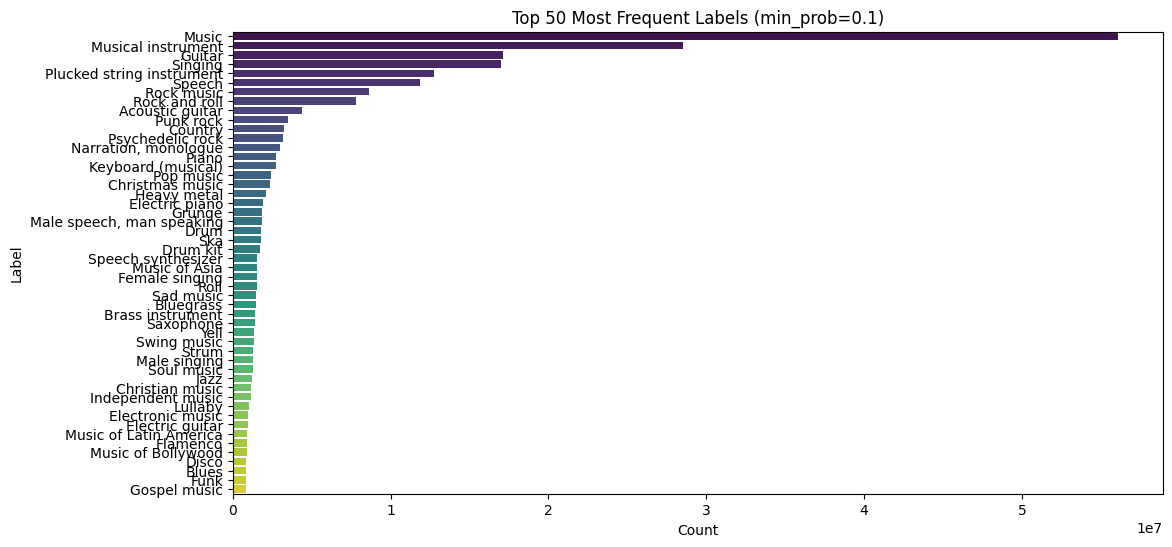

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Parameters
top_k = 50
min_prob = 0.1

# Example: sound_events is a dict {filename: [[{label: prob}, ...], ...]} per segment
all_labels = []

for file_segments in sound_events.values():
    for segment in file_segments:  # list of events per segment
        for event in segment:      # each event is a dict {label: prob}
            for label, prob in event.items():
                if prob >= min_prob:
                    all_labels.append(label)

# Count frequency
label_counts = Counter(all_labels)
top_labels = label_counts.most_common(top_k)

# Convert to DataFrame for plotting
df_labels = pd.DataFrame(top_labels, columns=['label', 'count'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=df_labels, x='count', y='label', palette='viridis')
plt.title(f"Top {top_k} Most Frequent Labels (min_prob={min_prob})")
plt.xlabel("Count")
plt.ylabel("Label")
plt.show()


In [ ]:
from pathlib import Path
import json
from anytree import PreOrderIter
from anytree.importer import JsonImporter
from anytree.search import find_by_attr


def load_ontology(ontology_path: Path = Path("metadata/Audioset_ontology.json")):
    importer = JsonImporter()
    with open(ontology_path, "r") as infile:
        tree_dict = json.load(infile)
    root = importer.import_(json.dumps(tree_dict))
    return root

def find_node(root, name):
    node = find_by_attr(root, name, name="name")
    if node is None:
        raise RuntimeError(f"Node '{name}' not found.")
    return node

def build_family(root, family_root_raw_name):
    family_root = find_node(root, family_root_raw_name)
    return {node.name for node in PreOrderIter(family_root)}

ontology_root = load_ontology(Path("data/sound_events/Audioset_ontology.json"))
music_tags = build_family(ontology_root, "Music")
singing_tags = build_family(ontology_root, "Singing")
humming_tags = build_family(ontology_root, "Humming")
interested_tags = music_tags | singing_tags | humming_tags
print(f"Identified {len(interested_tags)} interested tags (music, singing, humming).")


In [41]:
def segment_to_binary(segment_preds, interested_tags, k=1):
    """
    Convert a single segment prediction to binary: 1 = music, 0 = non-music
    segment_preds: list of dicts like [{label: prob}, ...]
    """
    top_k_labels = {list(pred.keys())[0] for pred in segment_preds[:k]}
    return int(bool(top_k_labels & interested_tags))

# Apply per file
k = 1
df_with_sound_events["music_binary"] = df_with_sound_events["sound_events"].apply(
    lambda segments: [segment_to_binary(seg, interested_tags, k) for seg in segments]
)

# Optionally, compute fraction of non-music (bad) segments per file
df_with_sound_events["fraction_non_music"] = df_with_sound_events["music_binary"].apply(
    lambda lst: 1 - sum(lst)/len(lst) if lst else 0
)

# Compute max consecutive music segments
SHINGLE_DURATION = 10  # seconds, example
SHINGLE_HOP = 1        # seconds, example

def max_consecutive_music(binary_list):
    consecutive = 0
    max_consec = 0
    for val in binary_list:
        if val == 1:
            if consecutive == 0:
                consecutive = SHINGLE_DURATION
            else:
                consecutive += SHINGLE_HOP
            max_consec = max(max_consec, consecutive)
        else:
            consecutive = 0
    return max_consec

df_with_sound_events["max_consecutive_music"] = df_with_sound_events["music_binary"].apply(max_consecutive_music)



## Non-Musical Content

### Fraction of non-musical content

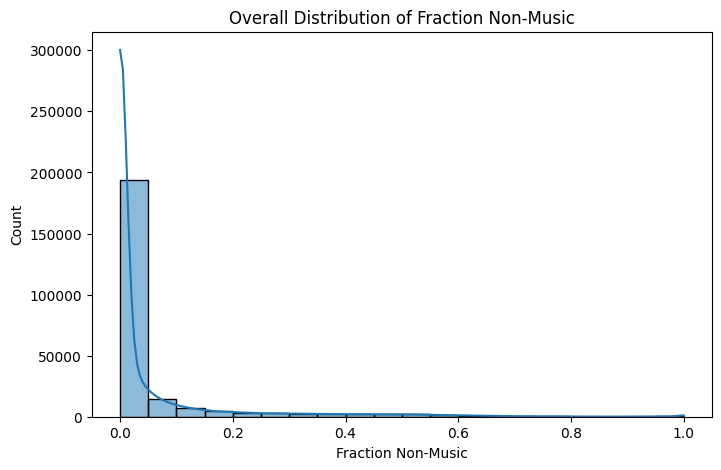

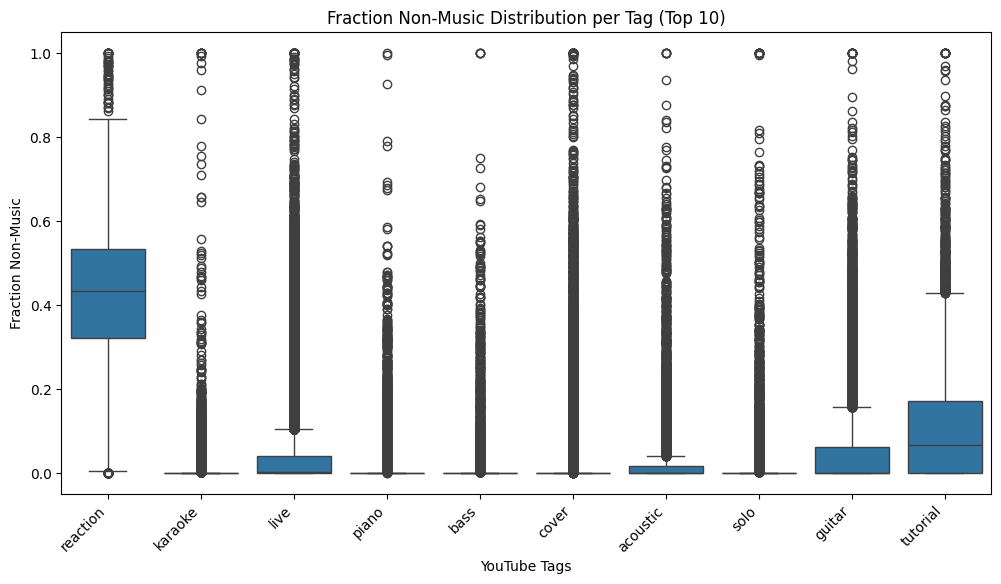

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# overall
plt.figure(figsize=(8,5))
sns.histplot(df_with_sound_events['fraction_non_music'], bins=20, kde=True)
plt.title("Overall Distribution of Fraction Non-Music")
plt.xlabel("Fraction Non-Music")
plt.ylabel("Count")
plt.show()

# per tag, for top n tags
top_n = 10
df_tags_exploded = df_with_sound_events.explode('tags_yt_title')
top_tags = df_tags_exploded['tags_yt_title'].value_counts().nlargest(top_n).index
df_top_tags = df_tags_exploded[df_tags_exploded['tags_yt_title'].isin(top_tags)]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_top_tags,
    x='tags_yt_title',
    y='fraction_non_music'
)
plt.title(f"Fraction Non-Music Distribution per Tag (Top {top_n})")
plt.xticks(rotation=45, ha='right')
plt.xlabel("YouTube Tags")
plt.ylabel("Fraction Non-Music")
plt.show()


### Maximum consecutive seconds of music

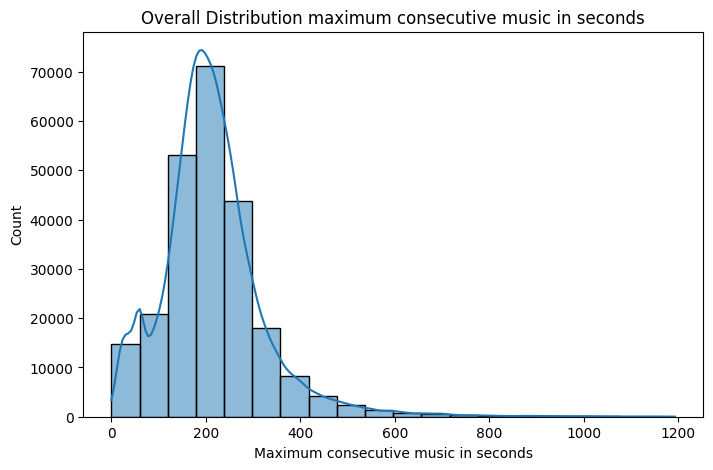

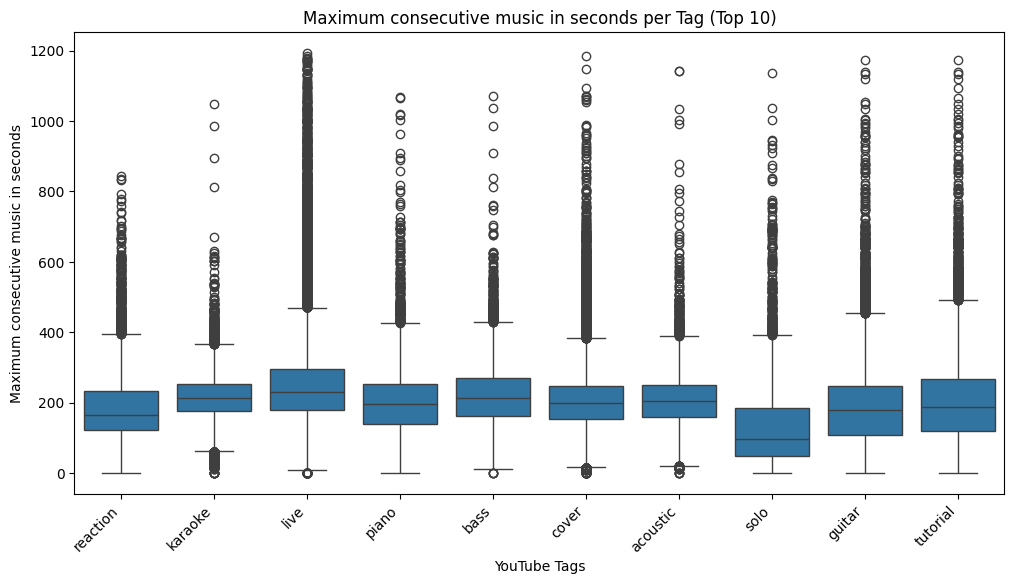

In [54]:
# overall
plt.figure(figsize=(8,5))
sns.histplot(df_with_sound_events['max_consecutive_music'], bins=20, kde=True)
plt.title("Overall Distribution maximum consecutive music in seconds")
plt.xlabel("Maximum consecutive music in seconds")
plt.ylabel("Count")
plt.show()

# per tag, for top n tags
top_n = 10
df_tags_exploded = df_with_sound_events.explode('tags_yt_title')
top_tags = df_tags_exploded['tags_yt_title'].value_counts().nlargest(top_n).index
df_top_tags = df_tags_exploded[df_tags_exploded['tags_yt_title'].isin(top_tags)]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_top_tags,
    x='tags_yt_title',
    y='max_consecutive_music'
)
plt.title(f"Maximum consecutive music in seconds per Tag (Top {top_n})")
plt.xticks(rotation=45, ha='right')
plt.xlabel("YouTube Tags")
plt.ylabel("Maximum consecutive music in seconds")
plt.show()